Carregando datasets...
Formato do set de treino: (147613, 51)
Formato do set de teste:  (63267, 51)

Processamento, encoding de features e scaling...
Features depois do encoding e scaling: 64

Treinando Mini-Batch K-Means Clustering (k=2)
Fazendo fit no modelo (Aprendizado Não-Supervisionado em Lotes)...
Mapeando Clusters para Labels baseadas na maioria...
  -> Cluster 0 mapeado para: Normal (0)
  -> Cluster 1 mapeado para: Ataque (1)

Predizendo clusters no conjunto de teste misto...

--- Relatório - Clustering Binário (Mini-Batch K-Means) ---
              precision    recall  f1-score   support

  Normal (0)       0.59      0.99      0.74     30351
  Ataque (1)       0.98      0.37      0.54     32916

    accuracy                           0.67     63267
   macro avg       0.79      0.68      0.64     63267
weighted avg       0.80      0.67      0.64     63267



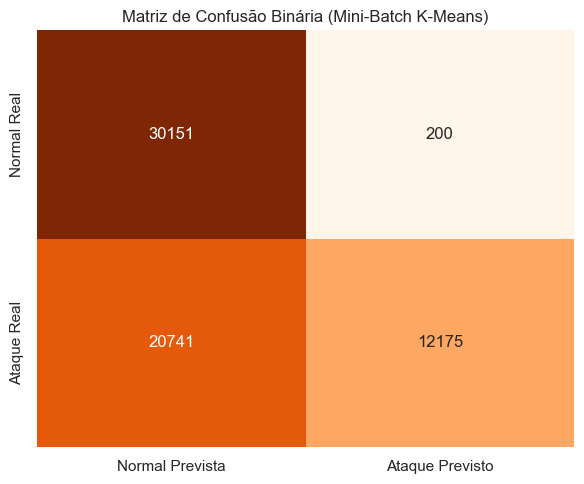


Análise de Distância para os Centroides
Distância Média do Tráfego Normal Real para o Centroide Normal: 4.993
Distância Média dos Ataques Reais para o Centroide Normal:      6.281
(Se o modelo funcionou bem, os ataques devem estar significativamente mais distantes)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import shuffle

# Set visualization style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. CARREGANDO DATASETS
# ==========================================
print("Carregando datasets...")
train_df = pd.read_csv("ubuntu-server_training-set.csv")
test_df = pd.read_csv("ubuntu-server_testing-set.csv")

print(f"Formato do set de treino: {train_df.shape}")
print(f"Formato do set de teste:  {test_df.shape}")

# ==========================================
# 2. PROCESSAMENTO DE DADOS, ENCODING E SCALING
# ==========================================
print("\nProcessamento, encoding de features e scaling...")

targets = ['label', 'attack_cat']
identities = ['id', 'srcip', 'sport', 'dstip', 'dsport', 'stime', 'ltime', 'ct_state_ttl']
drop_cols = targets + identities

# Separa features X e alvos y, ignorando colunas se já estiverem droppadas
X_train = train_df.drop(columns=[col for col in drop_cols if col in train_df.columns])
y_train_bin = train_df['label']

X_test = test_df.drop(columns=[col for col in drop_cols if col in test_df.columns])
y_test_bin = test_df['label']

cat_cols = ['proto', 'service', 'state']

# One-Hot para features categóricas
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols)

# Alinha as colunas de treino e teste
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# SCALING: Requisito absoluto para algoritmos baseados em distância
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print(f"Features depois do encoding e scaling: {X_train_scaled.shape[1]}")

# ==========================================
# 3. CLUSTERING BINÁRIO (MINI-BATCH K-MEANS)
# ==========================================
print("\n" + "="*50)
print("Treinando Mini-Batch K-Means Clustering (k=2)")
print("="*50)

# Inicializa Mini-Batch K-Means
# batch_size=2048: Processa 2048 conexões por vez, otimizando o uso de RAM e CPU
mb_kmeans = MiniBatchKMeans(
    n_clusters=2, 
    init='k-means++', 
    batch_size=2048,
    n_init=10, 
    random_state=42
)

print("Fazendo fit no modelo (Aprendizado Não-Supervisionado em Lotes)...")
# Note que NÃO passamos y_train_bin aqui. Ele aprende puramente pelo formato/distância dos dados.
train_clusters = mb_kmeans.fit_predict(X_train_scaled)

# --- MAPEAMENTO DE CLUSTERS PARA LABELS ---
print("Mapeando Clusters para Labels baseadas na maioria...")
# Precisamos descobrir se o Cluster 0 é "Normal" ou "Ataque"
cluster_0_true_labels = y_train_bin[train_clusters == 0]
cluster_1_true_labels = y_train_bin[train_clusters == 1]

# Encontra a label real mais frequente dentro de cada cluster
cluster_0_majority = cluster_0_true_labels.mode()[0] if not cluster_0_true_labels.empty else 0
cluster_1_majority = cluster_1_true_labels.mode()[0] if not cluster_1_true_labels.empty else 1

cluster_map = {
    0: cluster_0_majority,
    1: cluster_1_majority
}

print(f"  -> Cluster 0 mapeado para: {'Ataque (1)' if cluster_map[0] == 1 else 'Normal (0)'}")
print(f"  -> Cluster 1 mapeado para: {'Ataque (1)' if cluster_map[1] == 1 else 'Normal (0)'}")

# Aviso caso o K-Means não consiga separar as classes
if cluster_map[0] == cluster_map[1]:
    print("\n[AVISO CRÍTICO] O Mini-Batch K-Means agrupou a maioria do Tráfego Normal E Ataques no mesmo cluster.")
    print("Isso indica que as classes não são separáveis esfericamente com k=2 nestes dados.")

print("\nPredizendo clusters no conjunto de teste misto...")
test_clusters = mb_kmeans.predict(X_test_scaled)

# Converte os clusters brutos (0/1 arbitrários) para as nossas labels reais (0/1) usando o mapa
y_pred_bin = np.vectorize(cluster_map.get)(test_clusters)

# ==========================================
# 4. MÉTRICAS E AVALIAÇÃO
# ==========================================
print("\n--- Relatório - Clustering Binário (Mini-Batch K-Means) ---")
print(classification_report(y_test_bin, y_pred_bin, target_names=['Normal (0)', 'Ataque (1)']))

# Matriz de Confusão Binária
plt.figure(figsize=(6, 5))
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
sns.heatmap(cm_bin, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Normal Prevista', 'Ataque Previsto'],
            yticklabels=['Normal Real', 'Ataque Real'])
plt.title('Matriz de Confusão Binária (Mini-Batch K-Means)')
plt.tight_layout()
plt.show()

# ==========================================
# 5. EXPLICABILIDADE: DISTÂNCIA PARA OS CENTROIDES
# ==========================================
print("\n" + "="*50)
print("Análise de Distância para os Centroides")
print("="*50)

# O transform calcula a distância de cada ponto para todos os centroides
distances = mb_kmeans.transform(X_test_scaled)

# Pega apenas a coluna de distâncias referente ao cluster "Normal"
normal_cluster_idx = 0 if cluster_map[0] == 0 else 1
distances_to_normal = distances[:, normal_cluster_idx]

test_df_distances = pd.DataFrame({'Label': y_test_bin, 'Dist_to_Normal': distances_to_normal})

avg_dist_normal = test_df_distances[test_df_distances['Label'] == 0]['Dist_to_Normal'].mean()
avg_dist_attack = test_df_distances[test_df_distances['Label'] == 1]['Dist_to_Normal'].mean()

print(f"Distância Média do Tráfego Normal Real para o Centroide Normal: {avg_dist_normal:.3f}")
print(f"Distância Média dos Ataques Reais para o Centroide Normal:      {avg_dist_attack:.3f}")
print("(Se o modelo funcionou bem, os ataques devem estar significativamente mais distantes)")


Gerando Cenário de Rede Desbalanceado (mais tráfego benigno) para o NIDS
Total de logs na simulação: 30970
Tráfego Normal: 30350 (98.00%)
Tráfego de Ataque: 620 (2.00%)

Filtro de Redução por Limiar de Confiança (Entropia)
Limiar de Incerteza (Tau): 0.4
Volume Original na Simulação: 30970
Logs Retidos (Alertas + Dúvidas): 4482 (14.47%)
Logs Reduzidos (Arquivados/Descartados): 26488 (85.53%)

Log Reduction Rate (LRR): 85.53%

Verificação de Segurança do Filtro
Total de Ataques Reais na Simulação: 620
Ataques Retidos (Sucesso): 283 (45.65%)
Ataques que ESCAPARAM (Falha do Filtro): 337 (54.35%)


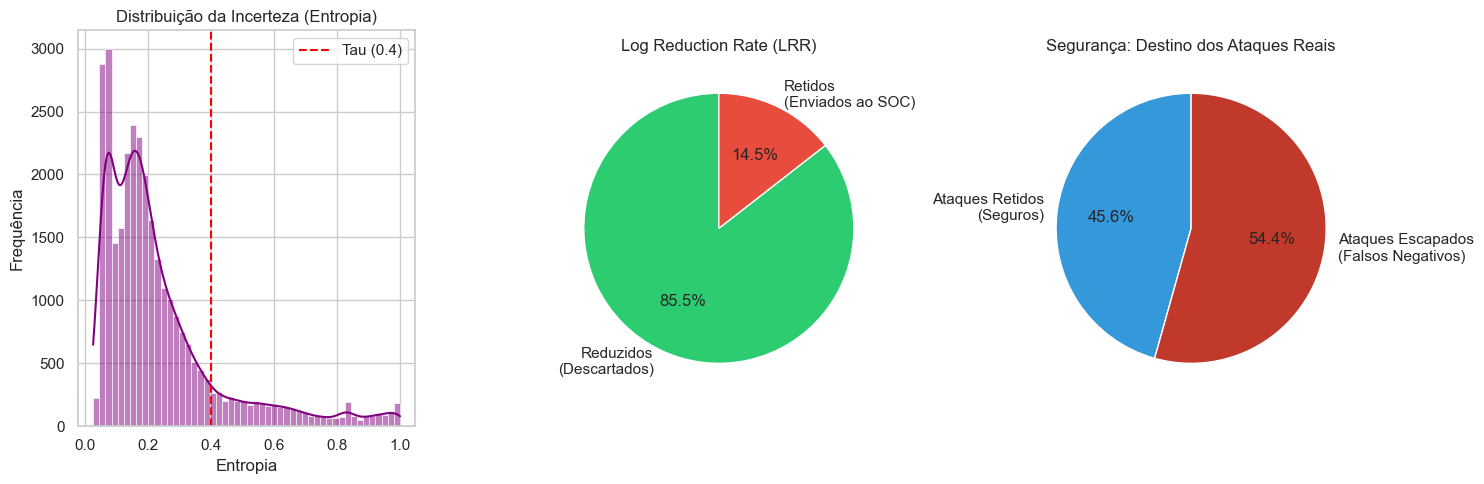


Calculando Curvas de Trade-off (RVL vs ARD) para Otimização


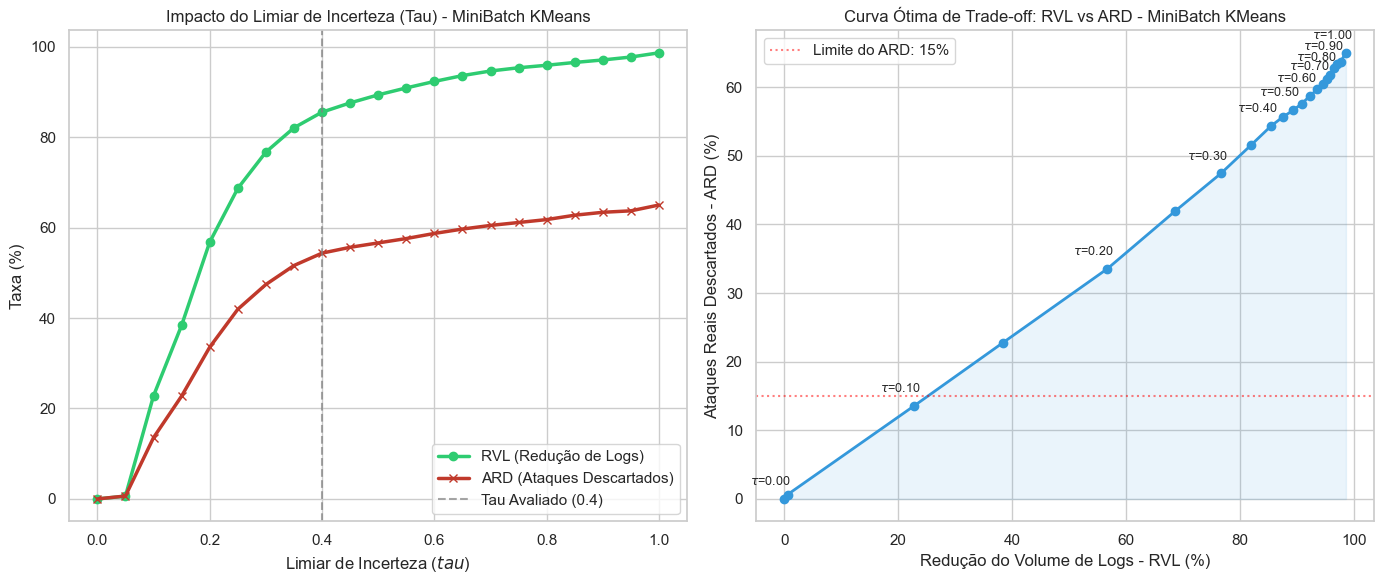

Ponto Ótimo Sugerido (ARD <= 15.0%): Tau = 0.10 | RVL = 22.79% | ARD = 13.55%

Exportando dados de Trade-off (Tau, RVL, ARD) para CSV
Dados exportados com sucesso para: tradeoff_mbkm.csv


In [2]:
# ==========================================
# 6. SIMULAÇÃO DE CENÁRIO REALISTA (Desbalanceado)
# ==========================================
print("\n" + "="*50)
print("Gerando Cenário de Rede Desbalanceado (mais tráfego benigno) para o NIDS")
print("="*50)

# Usamos o X_test_encoded ANTES do scaling para amostragem limpa
test_analysis_df = X_test_encoded.copy()
test_analysis_df['label'] = y_test_bin

# Separando tráfego normal e de ataque
normal_data = test_analysis_df[test_analysis_df['label'] == 0]
attack_data = test_analysis_df[test_analysis_df['label'] == 1]

# Proporção realista
prop_normal = 0.98
total_sim_logs = int(len(normal_data) / prop_normal) 

if total_sim_logs > len(test_analysis_df):
    total_sim_logs = len(test_analysis_df)

n_normal = int(total_sim_logs * prop_normal)
n_attack = total_sim_logs - n_normal

normal_sample = normal_data.sample(n=n_normal, random_state=42, replace=(n_normal > len(normal_data)))
attack_sample = attack_data.sample(n=n_attack, random_state=42, replace=(n_attack > len(attack_data)))

sim_df = pd.concat([normal_sample, attack_sample])
sim_df = shuffle(sim_df, random_state=42).reset_index(drop=True)

# Separando X (features) e Y (labels reais) do cenário simulado
X_sim = sim_df.drop(columns=['label'])
y_sim_bin = sim_df['label'].values

# IMPORTANTE PARA O K-MEANS: Aplicar o scaler treinado na simulação
X_sim_scaled = scaler.transform(X_sim)

print(f"Total de logs na simulação: {len(sim_df)}")
print(f"Tráfego Normal: {len(normal_sample)} ({(len(normal_sample)/len(sim_df))*100:.2f}%)")
print(f"Tráfego de Ataque: {len(attack_sample)} ({(len(attack_sample)/len(sim_df))*100:.2f}%)")

# ==========================================
# 7. FILTRO LOGS BASEADO EM ENTROPIA (Adaptação MB K-Means)
# ==========================================
print("\n" + "="*50)
print("Filtro de Redução por Limiar de Confiança (Entropia)")
print("="*50)

# O transform() retorna uma matriz com a distância do log para o Cluster 0 e para o Cluster 1.
distances_sim = mb_kmeans.transform(X_sim_scaled)

# CORREÇÃO PARA ALTA DIMENSIONALIDADE: Softmax com Fator Beta
# Você calibrou o beta para 1.0 (não precisa de amplificação extrema)
beta = 1.0

# Aplicamos exponencial negativa (quanto menor a distância, maior a probabilidade resultante)
exp_distances = np.exp(-beta * distances_sim)

# Normaliza para que a soma seja 1 (100%)
probs_raw = exp_distances / np.sum(exp_distances, axis=1, keepdims=True)

# Identificamos qual coluna pertence ao tráfego Normal e qual ao Ataque usando o mapa
normal_cluster_idx = 0 if cluster_map[0] == 0 else 1
attack_cluster_idx = 1 if normal_cluster_idx == 0 else 0

prob_normal = probs_raw[:, normal_cluster_idx]
prob_ataque = probs_raw[:, attack_cluster_idx]

# Combina as probabilidades no padrão unificado [prob_normal, prob_ataque]
probs_sim = np.vstack((prob_normal, prob_ataque)).T

# Calcular a Entropia de Shannon (Incerteza)
entropies_sim = scipy.stats.entropy(probs_sim, base=2, axis=1)

# Definir o Limiar de Confiança (Tau)
# Você ajustou empiricamente o tau para 0.4 para obter resultados adequados ao seu dataset
tau = 0.4

# Condição para reter o log:
# Probabilidade da classe 1 (Ataque) > 50%  OU  Entropia >= tau (Dúvida do modelo)
alert_mask_sim = (probs_sim[:, 1] > 0.5) | (entropies_sim >= tau)

# Máscaras booleanas de retenção e descarte
logs_retained_mask = alert_mask_sim
logs_dropped_mask = ~alert_mask_sim

total_logs_sim = len(y_sim_bin)
logs_retained_count = np.sum(logs_retained_mask)
logs_dropped_count = np.sum(logs_dropped_mask)

# Log Reduction Rate (LRR)
log_reduction_rate = (logs_dropped_count / total_logs_sim) * 100

print(f"Limiar de Incerteza (Tau): {tau}")
print(f"Volume Original na Simulação: {total_logs_sim}")
print(f"Logs Retidos (Alertas + Dúvidas): {logs_retained_count} ({(logs_retained_count/total_logs_sim)*100:.2f}%)")
print(f"Logs Reduzidos (Arquivados/Descartados): {logs_dropped_count} ({(logs_dropped_count/total_logs_sim)*100:.2f}%)\n")
print(f"Log Reduction Rate (LRR): {log_reduction_rate:.2f}%")

# ==========================================
# 8. VERIFICAÇÃO DE SEGURANÇA (False Negatives do Filtro)
# ==========================================
print("\n" + "="*50)
print("Verificação de Segurança do Filtro")
print("="*50)

# Máscara de onde os ataques REAIS estão
real_attacks_mask = (y_sim_bin == 1)
total_real_attacks = np.sum(real_attacks_mask)

# Ataques que foram descartados (Falso Negativo Crítico do pipeline)
escaped_attacks_mask = real_attacks_mask & logs_dropped_mask
escaped_attacks_count = np.sum(escaped_attacks_mask)

# Ataques que foram retidos com sucesso
caught_attacks_count = total_real_attacks - escaped_attacks_count
escape_rate = (escaped_attacks_count / total_real_attacks) * 100 if total_real_attacks > 0 else 0

print(f"Total de Ataques Reais na Simulação: {total_real_attacks}")
print(f"Ataques Retidos (Sucesso): {caught_attacks_count} ({(caught_attacks_count/total_real_attacks)*100:.2f}%)")
print(f"Ataques que ESCAPARAM (Falha do Filtro): {escaped_attacks_count} ({escape_rate:.2f}%)")

# ==========================================
# 9. VISUALIZAÇÕES DE IMPACTO
# ==========================================
plt.figure(figsize=(15, 5))

# Gráfico 1: Distribuição da Entropia
plt.subplot(1, 3, 1)
sns.histplot(entropies_sim, bins=50, kde=True, color='purple')
plt.axvline(x=tau, color='red', linestyle='--', label=f'Tau ({tau})')
plt.title('Distribuição da Incerteza (Entropia)')
plt.xlabel('Entropia')
plt.ylabel('Frequência')
plt.legend()

# Gráfico 2: Eficiência da Redução de Logs
plt.subplot(1, 3, 2)
plt.pie([logs_dropped_count, logs_retained_count], 
        labels=['Reduzidos\n(Descartados)', 'Retidos\n(Enviados ao SOC)'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Log Reduction Rate (LRR)')

# Gráfico 3: Impacto na Segurança
plt.subplot(1, 3, 3)
plt.pie([caught_attacks_count, escaped_attacks_count], 
        labels=['Ataques Retidos\n(Seguros)', 'Ataques Escapados\n(Falsos Negativos)'],
        autopct='%1.1f%%', colors=['#3498db', '#c0392b'], startangle=90)
plt.title('Segurança: Destino dos Ataques Reais')

plt.tight_layout()
plt.show()

# ==========================================
# 10. ANÁLISE DE TRADE-OFF (CURVA DE OTIMIZAÇÃO)
# ==========================================
print("\n" + "="*50)
print("Calculando Curvas de Trade-off (RVL vs ARD) para Otimização")
print("="*50)

# Array com valores de Tau de 0.0 até 1.0 com passos de 0.05
tau_values = np.arange(0.0, 1.05, 0.05)
lrr_list = []
ard_list = []

# Iterando sobre cada possível Tau para calcular as métricas
for t in tau_values:
    # Máscara de alerta para o Tau atual
    current_alert_mask = (probs_sim[:, 1] > 0.5) | (entropies_sim >= t)
    current_dropped_mask = ~current_alert_mask
    
    # Cálculo do RVL (Redução de Logs)
    current_lrr = (np.sum(current_dropped_mask) / total_logs_sim) * 100
    lrr_list.append(current_lrr)
    
    # Cálculo do ARD (Ataques Descartados)
    current_escaped = np.sum(real_attacks_mask & current_dropped_mask)
    current_ard = (current_escaped / total_real_attacks) * 100 if total_real_attacks > 0 else 0
    ard_list.append(current_ard)

# Plotando os Gráficos de Otimização
plt.figure(figsize=(14, 6))

# Gráfico A: Comportamento Dinâmico por Tau
plt.subplot(1, 2, 1)
plt.plot(tau_values, lrr_list, label='RVL (Redução de Logs)', color='#2ecc71', linewidth=2.5, marker='o')
plt.plot(tau_values, ard_list, label='ARD (Ataques Descartados)', color='#c0392b', linewidth=2.5, marker='x')
plt.axvline(x=tau, color='gray', linestyle='--', alpha=0.7, label=f'Tau Avaliado ({tau})')
plt.title('Impacto do Limiar de Incerteza (Tau) - MiniBatch KMeans')
plt.xlabel('Limiar de Incerteza ($tau$)')
plt.ylabel('Taxa (%)')
plt.legend()

# Gráfico B: Curva de Pareto (Trade-off Direto RVL vs ARD)
plt.subplot(1, 2, 2)
plt.plot(lrr_list, ard_list, color='#3498db', linewidth=2, marker='o', markersize=6)
plt.fill_between(lrr_list, ard_list, color='#3498db', alpha=0.1) # Destaque visual leve

# Anotando os valores de tau nos pontos do gráfico
for i, t in enumerate(tau_values):
    # Condição para anotar apenas se houver mudança significativa ou passos grandes
    if i % 2 == 0 or t == 1.0: 
        plt.annotate(f"$\\tau$={t:.2f}", (lrr_list[i], ard_list[i]), 
                     textcoords="offset points", xytext=(-10,10), ha='center', fontsize=9)

# Linha de aceitabilidade
plt.axhline(y=15.0, color='red', linestyle=':', alpha=0.5, label='Limite do ARD: 15%')

plt.title('Curva Ótima de Trade-off: RVL vs ARD - MiniBatch KMeans')
plt.xlabel('Redução do Volume de Logs - RVL (%)')
plt.ylabel('Ataques Reais Descartados - ARD (%)')
plt.legend()

plt.tight_layout()
plt.savefig('tradeoff_rvl_ard_mbkm.png', dpi=300, format='png', bbox_inches='tight')
plt.show()

# Resumo do Ponto Ótimo Automático
ard_limit = 15.0
valid_indices = [i for i, ard in enumerate(ard_list) if ard <= ard_limit]
if valid_indices:
    best_idx = max(valid_indices, key=lambda i: lrr_list[i]) # Pega o índice com maior RVL dentre os válidos
    best_tau = tau_values[best_idx]
    best_rvl = lrr_list[best_idx]
    best_ard = ard_list[best_idx]
    print(f"Ponto Ótimo Sugerido (ARD <= {ard_limit}%): Tau = {best_tau:.2f} | RVL = {best_rvl:.2f}% | ARD = {best_ard:.2f}%")
else:
    print(f"Não há ponto ótimo que mantenha os ataques descartados abaixo de {ard_limit}%.")

# ==========================================
# 11. EXPORTANDO DADOS PARA PLOTAGEM UNIFICADA
# ==========================================
print("\n" + "="*50)
print("Exportando dados de Trade-off (Tau, RVL, ARD) para CSV")
print("="*50)

# Criando um DataFrame com os dados calculados no bloco 10
tradeoff_df = pd.DataFrame({
    'Tau': tau_values,
    'RVL': lrr_list,
    'ARD': ard_list
})

nome_arquivo_csv = 'tradeoff_mbkm.csv'

# Exportando para CSV (sem salvar o índice para manter o arquivo limpo)
tradeoff_df.to_csv(nome_arquivo_csv, index=False)

print(f"Dados exportados com sucesso para: {nome_arquivo_csv}")